# EDA on Sample Dataset(titanic dataset)

## 1. Perform Data Cleaning,Data Aggregation and Filtering

In [1]:
!pip install pandas

In [2]:
import numpy 
import pandas as pd 

#### load titanic dataset

In [3]:
df= pd.read_csv(r"C:\Users\chand\Downloads\titanic.csv")

#### inspect data

In [4]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
df.shape

(891, 12)

In [7]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


#### Handle missing values

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [9]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


#### Remove duplicates

In [12]:
df = df.drop_duplicates()

#### filter data : passengers in first class

In [13]:
first_class = df[df["Pclass"]==1]
print("First class passengers: \n",first_class.head())

First class passengers: 
     PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
11           12         1       1   
23           24         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   
23                       Sloper, Mr. William Thompson    male  28.0      0   

    Parch    Ticket     Fare Cabin Embarked  
1       0  PC 17599  71.2833   C85        C  
3       0    113803  53.1000  C123        S  
6       0     17463  51.8625   E46        S  
11      0    113783  26.5500  C103        S  
23      0    113788  35.5000    A6        S  


### 2. Generate visualizations to illustrate Key Insights

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

##### a. Bar chart : survival rates by class

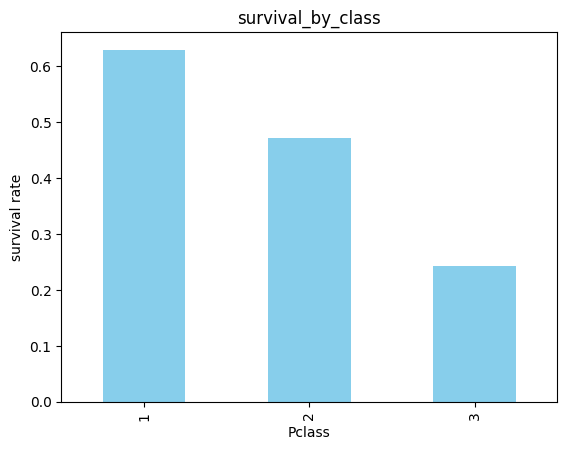

In [15]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar",color = "skyblue")
plt.ylabel("survival rate")
plt.title("survival_by_class")
plt.show()

##### b. Histogram plot : Age distribution

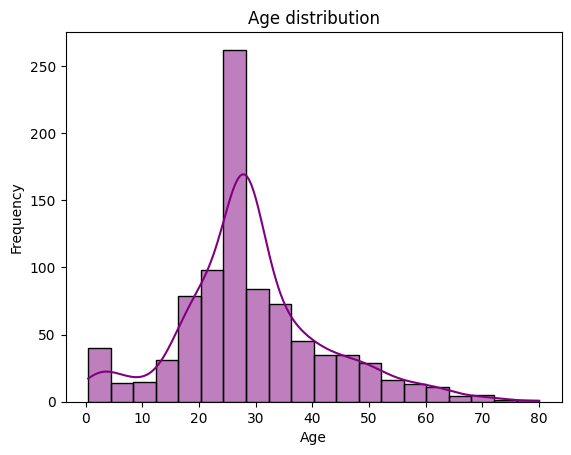

In [16]:
sns.histplot(df["Age"],kde = True,color = "purple",bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##### c. Scatter plot : Age vs Fare

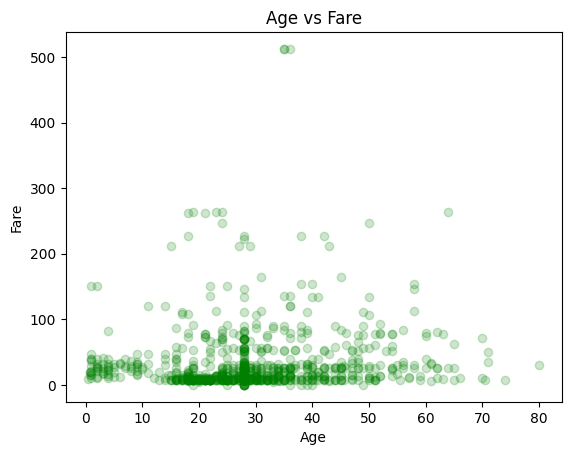

In [17]:
plt.scatter(df["Age"],df["Fare"],alpha = 0.2,color="green")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### 3. Identify and Interpret patterns or Anomalies

##### a. Correlation between numerical columns

In [18]:
correlation = (df.corr(numeric_only = True))

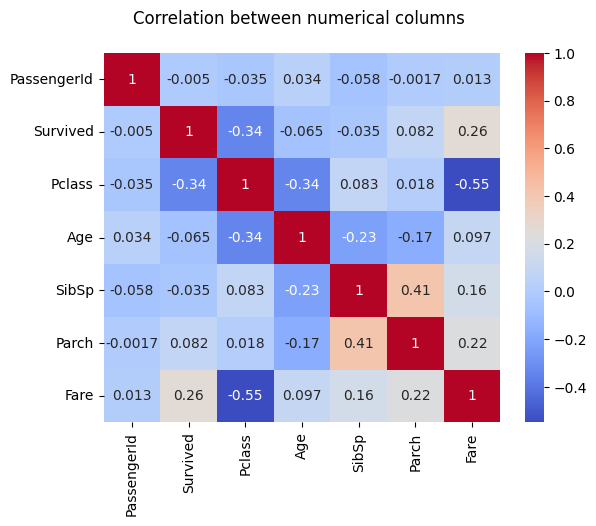

In [19]:
# correlation matrix
import seaborn as sns
import numpy as np
sns.heatmap(correlation,annot = True,cmap = "coolwarm")
plt.title("Correlation between numerical columns \n")
plt.show()

##### b. Survival rate by Passengers class

In [20]:
print("Survival rate by passengers class:")
print(df.groupby("Pclass")["Survived"].mean())

Survival rate by passengers class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


##### c. Average age by passengers class

In [21]:
print("Average age by passengers class:")
print(df.groupby("Pclass")["Age"].mean())

Average age by passengers class:
Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64


##### d. Detect outliers in Fare

In [22]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = df[(df["Fare"]>lower_bound) | (df["Fare"]<upper_bound)]
print("Number of Fare outliers:")
len(outliers)
print(outliers[["PassengerId","Fare"]].head())

Number of Fare outliers:
   PassengerId     Fare
0            1   7.2500
1            2  71.2833
2            3   7.9250
3            4  53.1000
4            5   8.0500


### 4. Summarize Findings in a report

In [23]:
with open("Titanic Dataset EDA Report.txt","r") as file:
    print(file.read())

Titanic Dataset EDA Report
1. overview
    - Dataset contents 891 rows and 12 columns.
    - Missing values handled for "Age" (filled with median) and "Embarked" (filled with mode).

2. Key Insights:
    - Survival rates are highest for first-class passengers (62%) and lower for third-class(24%).
    - Majority of passengers are aged between 20-40 years.
    - A positive correlation exists between fare and survival.

3. Visual Insights:
    - Bar chart : survival rates by class
    - Histogram plot : Age distribution
    - Scatter plot : Age vs Fare
    - Heatmap : Correlation between numerical columns

4 . Interactive Dashboard : 
    - Developed an interactive dashboard using Plotly Dash.
    - The dashboard presents key visualizations, including:
        a. Survival Rate by Passenger Class
        b. Age Distribution of Passengers
        c.Age vs. Fare Scatter Plot
    - The dashboard enables interactive data exploration through features such as zooming, panning, and hover tooltips